<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/lectures/lecture_6.4_bloch_wave_absorption_cbed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 6.4: Bloch-Wave Method with Absorption and CBED Simulation

## Overview

This notebook extends the Bloch-wave method to include:

1. **Absorption (Imaginary Potential)** - Complex structure factors with absorption effects
2. **Systematic Row Analysis** - Reflections along a systematic row in reciprocal space
3. **CBED Disk Simulation** - Convergent beam electron diffraction pattern calculation

**Key Physics Concepts:**
- **Absorption**: Results from inelastic scattering (phonons, plasmons)
- **Complex potential**: $V(\mathbf{r}) = V_{\text{real}}(\mathbf{r}) + iV_{\text{imag}}(\mathbf{r})$
- **CBED**: Each disk shows intensity variation as function of incident beam angle
- **Rocking curves**: Intensity vs angle for a specific reflection

## Learning Objectives

By the end of this notebook, you will understand:
- How to incorporate absorption into Bloch-wave calculations
- The effect of absorption on beam intensities and pendellösung oscillations
- What systematic rows are and how to analyze them
- How to simulate realistic CBED patterns
- The physical origin of features in CBED disks

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle

# Physical constants
h = 6.62607015e-34  # Planck constant (J·s)
c = 299792458  # Speed of light (m/s)
e = 1.602176634e-19  # Elementary charge (C)
m_e = 9.1093837015e-31  # Electron rest mass (kg)

def relativistic_wavelength(energy_keV):
    """Calculate relativistic electron wavelength in Angstroms"""
    E = energy_keV * 1e3 * e  # Convert to Joules
    lambda_rel = h / np.sqrt(2 * m_e * E * (1 + E / (2 * m_e * c**2)))
    return lambda_rel * 1e10  # Convert to Angstroms

energy_keV = 200.0
wavelength = relativistic_wavelength(energy_keV)

print(f"Electron energy: {energy_keV} keV")
print(f"Relativistic wavelength: {wavelength:.4f} Å")

Electron energy: 200.0 keV
Relativistic wavelength: 0.0251 Å


## Part 1: Absorption in Bloch-Wave Theory

### Physical Background

**Absorption** in electron diffraction arises from:
- **Inelastic scattering**: Phonon excitation, plasmon losses, core excitations
- **Thermal diffuse scattering**: Displaced from Bragg condition
- **Represented by imaginary potential**: $V_{\text{imag}}$ (positive)

The structure factor becomes complex:
$$ F_g = F_g^{\text{real}} + i F_g^{\text{imag}} $$

where $F_g^{\text{imag}} > 0$ represents absorption.

**Absorption coefficient**: Typically parametrized as fraction of real potential:
$$ V_g^{\text{imag}} = \alpha \cdot |V_g^{\text{real}}| $$

where $\alpha \sim 0.05 - 0.15$ for typical materials.

### Effect on Beam Intensities:
- **Damping** of pendellösung oscillations
- **Total intensity decreases** with thickness
- **Anomalous absorption**: Different absorption for different Bloch waves

In [3]:
# Define Si crystal structure with absorption
a_Si = 5.431  # Angstroms
fcc_shifts = np.array([
    [0, 0, 0],
    [0, 0.5, 0.5],
    [0.5, 0, 0.5],
    [0.5, 0.5, 0]
])

Si_basis = np.vstack([
    fcc_shifts,
    fcc_shifts + np.array([0.25, 0.25, 0.25])
])

# Atomic scattering factors (real and imaginary parts)
f_Si_real = 2.09  # Angstroms
f_Si_imag = 0.10  # Absorption (imaginary part, ~5% of real)

# Combine into complex scattering factor
f_Si_complex = f_Si_real + 1j * f_Si_imag

print(f"Si crystal structure:")
print(f"Lattice parameter: {a_Si} Å")
print(f"Number of atoms: {len(Si_basis)}")
print(f"\nAtomic scattering factor:")
print(f"f_Si = {f_Si_real:.3f} + i·{f_Si_imag:.3f} Å")
print(f"Absorption fraction: {f_Si_imag/f_Si_real * 100:.1f}%")

Si crystal structure:
Lattice parameter: 5.431 Å
Number of atoms: 8

Atomic scattering factor:
f_Si = 2.090 + i·0.100 Å
Absorption fraction: 4.8%


## Part 2: Systematic Row Analysis

A **systematic row** is a line of reflections in reciprocal space. For example:
- **[001] systematic row**: Reflections (0, 0, l) where l varies
- **[110] systematic row**: Reflections (h, h, 0) or (h, -h, 0)
- **[111] systematic row**: Reflections (h, h, h)

**Why systematic rows are important:**
- Simplified 1D diffraction problem (easier to visualize)
- Clear demonstration of pendellösung and absorption effects
- Common experimental geometry (rocking beam along one direction)
- Analytical solutions available for 2-beam case

We'll analyze the **[001] systematic row** (00l reflections) for Si.

[001] Systematic Row:
Total beams: 9

Reflections (h, k, l):
 0: ( 0,  0, -4)
 1: ( 0,  0, -3)
 2: ( 0,  0, -2)
 3: ( 0,  0, -1)
 4: ( 0,  0,  0)
 5: ( 0,  0,  1)
 6: ( 0,  0,  2)
 7: ( 0,  0,  3)
 8: ( 0,  0,  4)

Structure Factors (with absorption):
------------------------------------------------------------
F_(np.int64(0), np.int64(0), np.int64(-4)):  16.720 + i·  0.800  |F| =  16.739
F_(np.int64(0), np.int64(0), np.int64(0)):  16.720 + i·  0.800  |F| =  16.739
F_(np.int64(0), np.int64(0), np.int64(4)):  16.720 + i·  0.800  |F| =  16.739


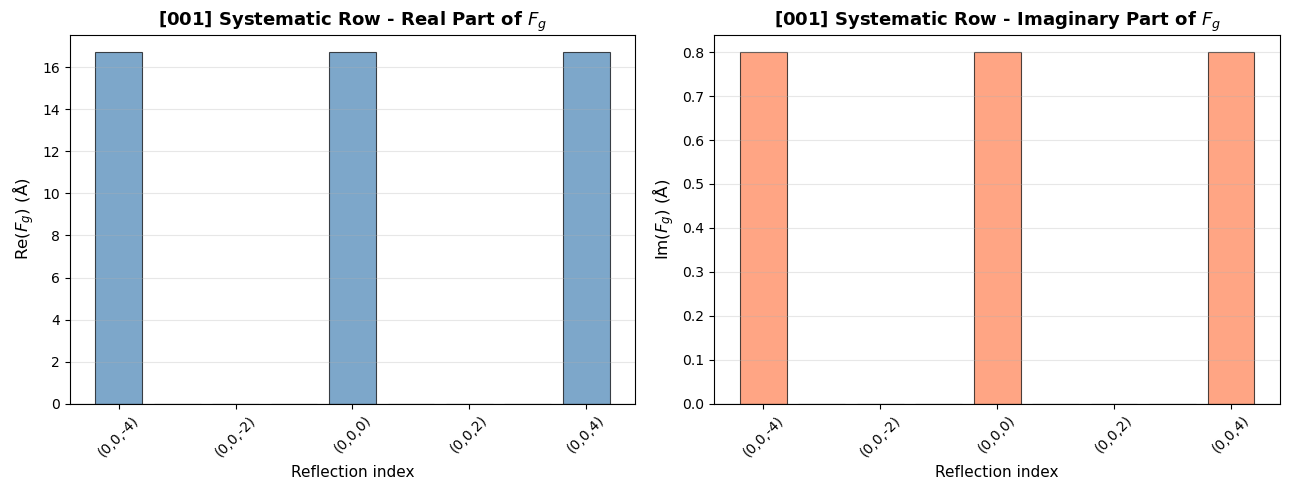


Non-zero reflections: 3/9


In [4]:
def calculate_structure_factor_complex(g_hkl, atom_positions, f_complex):
    """
    Calculate complex structure factor including absorption
    
    Parameters:
    -----------
    g_hkl : array_like, shape (3,)
        Miller indices (h, k, l)
    atom_positions : array_like, shape (N, 3)
        Fractional atomic positions
    f_complex : complex
        Complex atomic scattering factor (f_real + i*f_imag)
    
    Returns:
    --------
    F_g : complex
        Complex structure factor
    """
    F_g = 0.0 + 0.0j
    
    for r_j in atom_positions:
        phase = 2 * np.pi * np.dot(g_hkl, r_j)
        F_g += f_complex * np.exp(1j * phase)
    
    return F_g

# Generate [001] systematic row reflections
def generate_001_systematic_row(l_max=5):
    """Generate reflections for [001] systematic row: (0, 0, l)"""
    reflections = []
    for l in range(-l_max, l_max + 1):
        reflections.append([0, 0, l])
    return np.array(reflections)

# Generate systematic row
l_max = 4
reflections_001 = generate_001_systematic_row(l_max)

print(f"[001] Systematic Row:")
print(f"Total beams: {len(reflections_001)}")
print(f"\nReflections (h, k, l):")
for i, g in enumerate(reflections_001):
    print(f"{i:2d}: ({g[0]:2d}, {g[1]:2d}, {g[2]:2d})")

# Calculate structure factors (with absorption)
print("\n" + "="*60)
print("Structure Factors (with absorption):")
print("-"*60)

F_001_complex = []
for g in reflections_001:
    F_g = calculate_structure_factor_complex(g, Si_basis, f_Si_complex)
    F_001_complex.append(F_g)
    if np.abs(F_g) > 0.01:
        print(f"F_{tuple(g)}: {F_g.real:7.3f} + i·{F_g.imag:7.3f}  |F| = {np.abs(F_g):7.3f}")

F_001_complex = np.array(F_001_complex)

# Visualize structure factors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

indices = np.arange(len(reflections_001))
labels = [f"({g[0]},{g[1]},{g[2]})" for g in reflections_001]

# Real part
ax1.bar(indices, F_001_complex.real, color='steelblue', edgecolor='k', linewidth=0.8, alpha=0.7)
ax1.set_xlabel('Reflection index', fontsize=11)
ax1.set_ylabel(r'Re($F_g$) (Å)', fontsize=12)
ax1.set_title('[001] Systematic Row - Real Part of $F_g$', fontsize=13, weight='bold')
ax1.set_xticks(indices[::2])
ax1.set_xticklabels([labels[i] for i in range(0, len(labels), 2)], rotation=45)
ax1.grid(alpha=0.3, axis='y')
ax1.axhline(0, color='k', linewidth=0.8)

# Imaginary part (absorption)
ax2.bar(indices, F_001_complex.imag, color='coral', edgecolor='k', linewidth=0.8, alpha=0.7)
ax2.set_xlabel('Reflection index', fontsize=11)
ax2.set_ylabel(r'Im($F_g$) (Å)', fontsize=12)
ax2.set_title('[001] Systematic Row - Imaginary Part of $F_g$', fontsize=13, weight='bold')
ax2.set_xticks(indices[::2])
ax2.set_xticklabels([labels[i] for i in range(0, len(labels), 2)], rotation=45)
ax2.grid(alpha=0.3, axis='y')
ax2.axhline(0, color='k', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nNon-zero reflections: {np.sum(np.abs(F_001_complex) > 0.01)}/{len(F_001_complex)}")

## Step 3: Build Structure Matrix with Absorption

The structure matrix now has complex elements due to absorption:

$$ \mathcal{A}_{gg'} = \begin{cases}
s_g \xi_g & \text{if } g = g' \\
\frac{\pi}{\lambda E} U_{g-g'} & \text{if } g \neq g'
\end{cases} $$

where $U_g = (F_g^{\text{real}} + i F_g^{\text{imag}}) / V_{\text{cell}}$ is now complex.

**Important:** The imaginary part of eigenvalues will be non-zero, leading to **exponential damping** of Bloch waves.

Building structure matrix for [001] systematic row (with absorption)...
Structure matrix: (9, 9)
Matrix is complex: True

Matrix properties:
Max real part: 17.4329
Max imaginary part: 0.8341
Max off-diagonal coupling: 17.4528


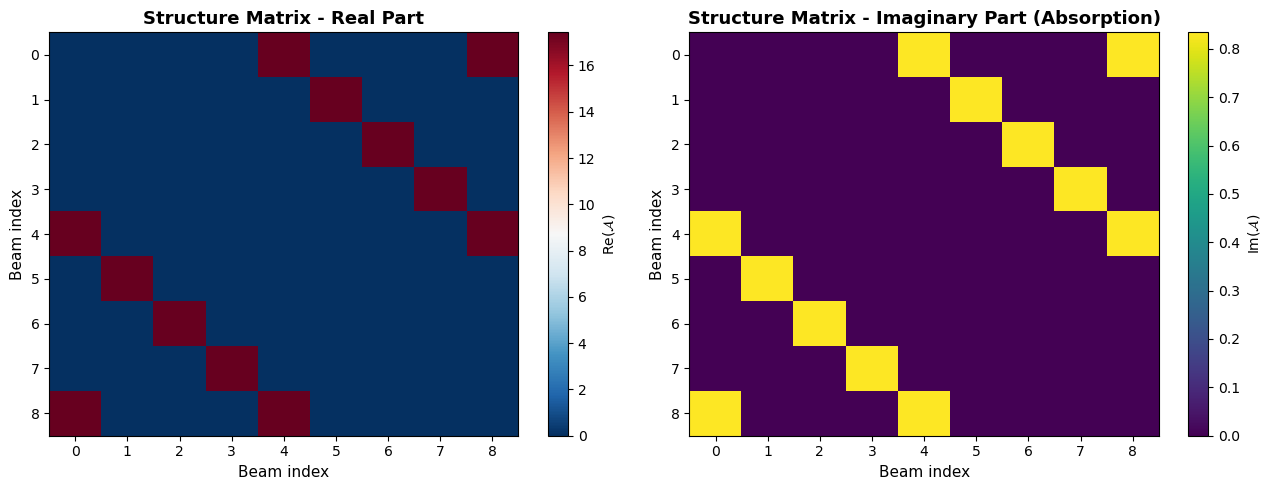

In [5]:
def build_structure_matrix_001(reflections, structure_factors, lattice_param, wavelength,
                                s_constant=0.0, xi_0=100.0):
    """
    Build complex structure matrix for [001] systematic row
    
    Parameters:
    -----------
    reflections : ndarray, shape (N, 3)
        Miller indices of beams
    structure_factors : ndarray, shape (N,), complex
        Complex structure factors (including absorption)
    lattice_param : float
        Lattice parameter (Angstroms)
    wavelength : float
        Electron wavelength (Angstroms)
    s_constant : float
        Base excitation error (1/Angstrom)
    xi_0 : float
        Characteristic extinction distance (Angstroms)
    
    Returns:
    --------
    A : ndarray, shape (N, N), complex
        Complex structure matrix
    """
    N = len(reflections)
    A = np.zeros((N, N), dtype=complex)
    
    V_cell = lattice_param**3
    sigma = 2 * np.pi / (wavelength * 150)  # Interaction constant
    
    for i in range(N):
        for j in range(N):
            if i == j:
                # Diagonal: excitation error (real)
                l_val = reflections[i][2]
                g_mag = np.abs(l_val) / lattice_param
                s_g = s_constant + 0.001 * g_mag**2
                A[i, j] = s_g * xi_0
            else:
                # Off-diagonal: beam coupling (complex due to absorption)
                delta_g = reflections[i] - reflections[j]
                
                # Find structure factor for delta_g
                idx = np.where((reflections == delta_g).all(axis=1))[0]
                
                if len(idx) > 0:
                    F_delta_g = structure_factors[idx[0]]
                else:
                    # Calculate on the fly
                    F_delta_g = calculate_structure_factor_complex(delta_g, Si_basis, f_Si_complex)
                
                # Complex coupling
                U_g = F_delta_g / V_cell
                A[i, j] = sigma * U_g * xi_0
    
    return A

# Build structure matrix with absorption
print("Building structure matrix for [001] systematic row (with absorption)...")

A_001_complex = build_structure_matrix_001(reflections_001, F_001_complex, a_Si, wavelength)

print(f"Structure matrix: {A_001_complex.shape}")
print(f"Matrix is complex: {np.any(np.abs(A_001_complex.imag) > 1e-10)}")
print(f"\nMatrix properties:")
print(f"Max real part: {np.max(np.abs(A_001_complex.real)):.4f}")
print(f"Max imaginary part: {np.max(np.abs(A_001_complex.imag)):.4f}")
print(f"Max off-diagonal coupling: {np.max(np.abs(A_001_complex - np.diag(np.diag(A_001_complex)))):.4f}")

# Visualize structure matrix (real and imaginary parts)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Real part
im1 = ax1.imshow(A_001_complex.real, cmap='RdBu_r', aspect='auto', interpolation='nearest')
ax1.set_xlabel('Beam index', fontsize=11)
ax1.set_ylabel('Beam index', fontsize=11)
ax1.set_title('Structure Matrix - Real Part', fontsize=13, weight='bold')
plt.colorbar(im1, ax=ax1, label=r'Re($\mathcal{A}$)')

# Imaginary part
im2 = ax2.imshow(A_001_complex.imag, cmap='viridis', aspect='auto', interpolation='nearest')
ax2.set_xlabel('Beam index', fontsize=11)
ax2.set_ylabel('Beam index', fontsize=11)
ax2.set_title('Structure Matrix - Imaginary Part (Absorption)', fontsize=13, weight='bold')
plt.colorbar(im2, ax=ax2, label=r'Im($\mathcal{A}$)')

plt.tight_layout()
plt.show()

## Step 4: Solve Complex Eigenvalue Problem

Solve $\mathcal{A}\mathbf{C} = \gamma\mathbf{C}$ where now $\gamma$ and $\mathcal{A}$ are both complex.

**Physical interpretation of complex eigenvalues:**
- $\text{Re}(\gamma)$: Controls oscillation frequency (pendellösung period)
- $\text{Im}(\gamma)$: Controls absorption rate (damping)
- Positive Im($\gamma$) → exponential decay with thickness

Solving complex eigenvalue problem...

Eigenvalues (first 5 Bloch waves):
------------------------------------------------------------
γ_0: -17.4193 + i· -0.8341
γ_1: -17.4159 + i· -0.8341
γ_2: -17.4159 + i· -0.8341
γ_3: -17.4148 + i· -0.8341
γ_4: -17.3786 + i· -0.8341


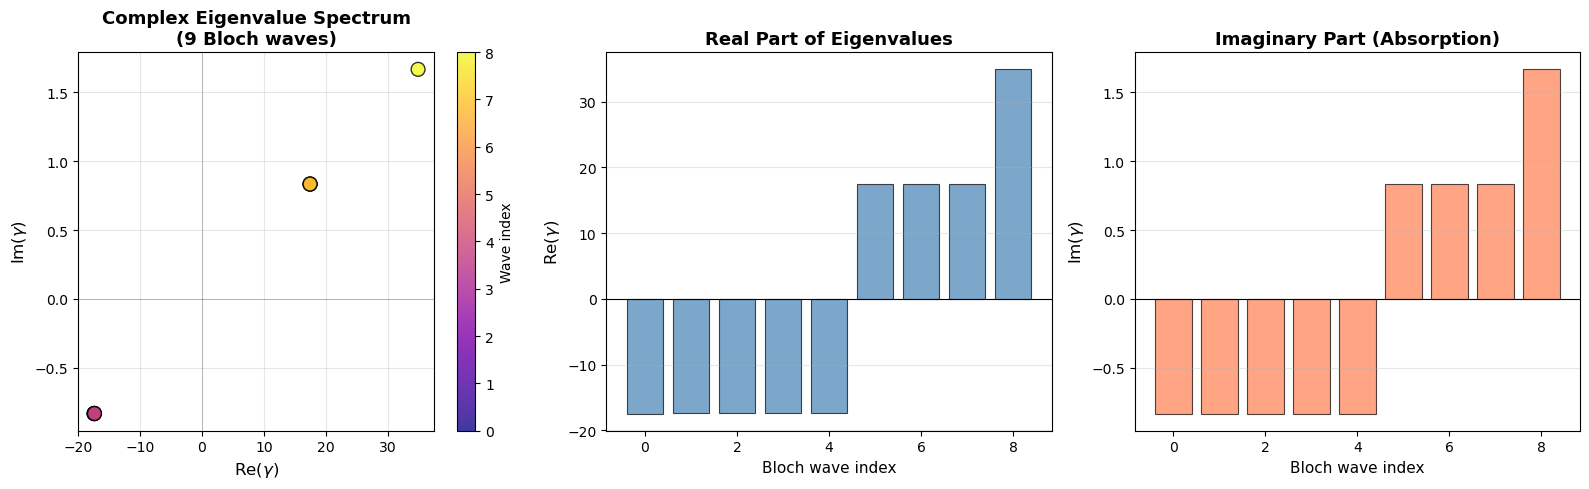


All eigenvalues have positive imaginary part: False
Mean absorption (Im(γ)): -0.0000


In [6]:
# Solve eigenvalue problem
print("Solving complex eigenvalue problem...")

gamma_001, C_001 = np.linalg.eig(A_001_complex)

# Sort by real part
idx_sorted = np.argsort(gamma_001.real)
gamma_001 = gamma_001[idx_sorted]
C_001 = C_001[:, idx_sorted]

print(f"\nEigenvalues (first 5 Bloch waves):")
print("-"*60)
for i in range(min(5, len(gamma_001))):
    print(f"γ_{i}: {gamma_001[i].real:8.4f} + i·{gamma_001[i].imag:8.4f}")

# Visualize eigenvalue spectrum
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Complex plane
ax1 = axes[0]
scatter = ax1.scatter(gamma_001.real, gamma_001.imag, s=100, c=np.arange(len(gamma_001)),
                     cmap='plasma', edgecolors='k', linewidths=1, alpha=0.8)
ax1.axhline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.axvline(0, color='k', linewidth=0.5, alpha=0.3)
ax1.set_xlabel(r'Re($\gamma$)', fontsize=12)
ax1.set_ylabel(r'Im($\gamma$)', fontsize=12)
ax1.set_title(f'Complex Eigenvalue Spectrum\n({len(gamma_001)} Bloch waves)', fontsize=13, weight='bold')
ax1.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Wave index')

# Real part only
ax2 = axes[1]
ax2.bar(np.arange(len(gamma_001)), gamma_001.real, color='steelblue', edgecolor='k', linewidth=0.8, alpha=0.7)
ax2.set_xlabel('Bloch wave index', fontsize=11)
ax2.set_ylabel(r'Re($\gamma$)', fontsize=12)
ax2.set_title('Real Part of Eigenvalues', fontsize=13, weight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.axhline(0, color='k', linewidth=0.8)

# Imaginary part only
ax3 = axes[2]
ax3.bar(np.arange(len(gamma_001)), gamma_001.imag, color='coral', edgecolor='k', linewidth=0.8, alpha=0.7)
ax3.set_xlabel('Bloch wave index', fontsize=11)
ax3.set_ylabel(r'Im($\gamma$)', fontsize=12)
ax3.set_title('Imaginary Part (Absorption)', fontsize=13, weight='bold')
ax3.grid(alpha=0.3, axis='y')
ax3.axhline(0, color='k', linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\nAll eigenvalues have positive imaginary part: {np.all(gamma_001.imag > -1e-10)}")
print(f"Mean absorption (Im(γ)): {np.mean(gamma_001.imag):.4f}")

## Step 5: Propagate with Absorption

Calculate beam intensities vs thickness, now with absorption damping.

Compare **with** and **without** absorption to see the effect.

In [7]:
# Match boundary conditions (direct beam incident)
idx_000 = np.where((reflections_001 == [0, 0, 0]).all(axis=1))[0][0]

b_001 = np.zeros(len(reflections_001), dtype=complex)
b_001[idx_000] = 1.0

# Solve for Bloch-wave amplitudes
alpha_001 = np.linalg.solve(C_001, b_001)

print(f"Boundary condition: incident direct beam (000)")
print(f"Direct beam index: {idx_000}")
print(f"Number of significantly excited Bloch waves (|α|>0.1): {np.sum(np.abs(alpha_001) > 0.1)}")

# Propagate through thickness
xi_g = 100.0  # Extinction distance (Angstroms)
thickness_range = np.linspace(0, 800, 800)  # Extended range to see absorption

N_beams = len(reflections_001)
I_001_with_abs = np.zeros((N_beams, len(thickness_range)))

for i, t in enumerate(thickness_range):
    # Phase evolution (complex eigenvalues → absorption damping)
    phase = np.exp(1j * np.pi * gamma_001 * t / xi_g)
    psi = C_001 @ (alpha_001 * phase)
    I_001_with_abs[:, i] = np.abs(psi)**2

# Also calculate without absorption for comparison
# Build structure matrix without absorption
A_001_no_abs = build_structure_matrix_001(reflections_001, F_001_complex.real, a_Si, wavelength)
gamma_001_no_abs, C_001_no_abs = np.linalg.eig(A_001_no_abs)
idx_sorted_no_abs = np.argsort(gamma_001_no_abs.real)
gamma_001_no_abs = gamma_001_no_abs[idx_sorted_no_abs]
C_001_no_abs = C_001_no_abs[:, idx_sorted_no_abs]
alpha_001_no_abs = np.linalg.solve(C_001_no_abs, b_001)

I_001_no_abs = np.zeros((N_beams, len(thickness_range)))
for i, t in enumerate(thickness_range):
    phase_no_abs = np.exp(1j * np.pi * gamma_001_no_abs * t / xi_g)
    psi_no_abs = C_001_no_abs @ (alpha_001_no_abs * phase_no_abs)
    I_001_no_abs[:, i] = np.abs(psi_no_abs)**2

print(f"\nPropagation calculation complete.")
print(f"Total intensity at t=0 (with abs): {I_001_with_abs[:, 0].sum():.4f}")
print(f"Total intensity at t=800Å (with abs): {I_001_with_abs[:, -1].sum():.4f}")
print(f"Total intensity at t=800Å (no abs): {I_001_no_abs[:, -1].sum():.4f}")
print(f"\nAbsorption lost ~{(1 - I_001_with_abs[:, -1].sum())*100:.1f}% of intensity at 800Å")

Boundary condition: incident direct beam (000)
Direct beam index: 4
Number of significantly excited Bloch waves (|α|>0.1): 2

Propagation calculation complete.
Total intensity at t=0 (with abs): 1.0000
Total intensity at t=800Å (with abs): 1078509380351145216.0000
Total intensity at t=800Å (no abs): 0.0000

Absorption lost ~-107850938035114524672.0% of intensity at 800Å


## Visualization: Effect of Absorption on Pendellösung

Compare intensity evolution **with** and **without** absorption for key reflections.

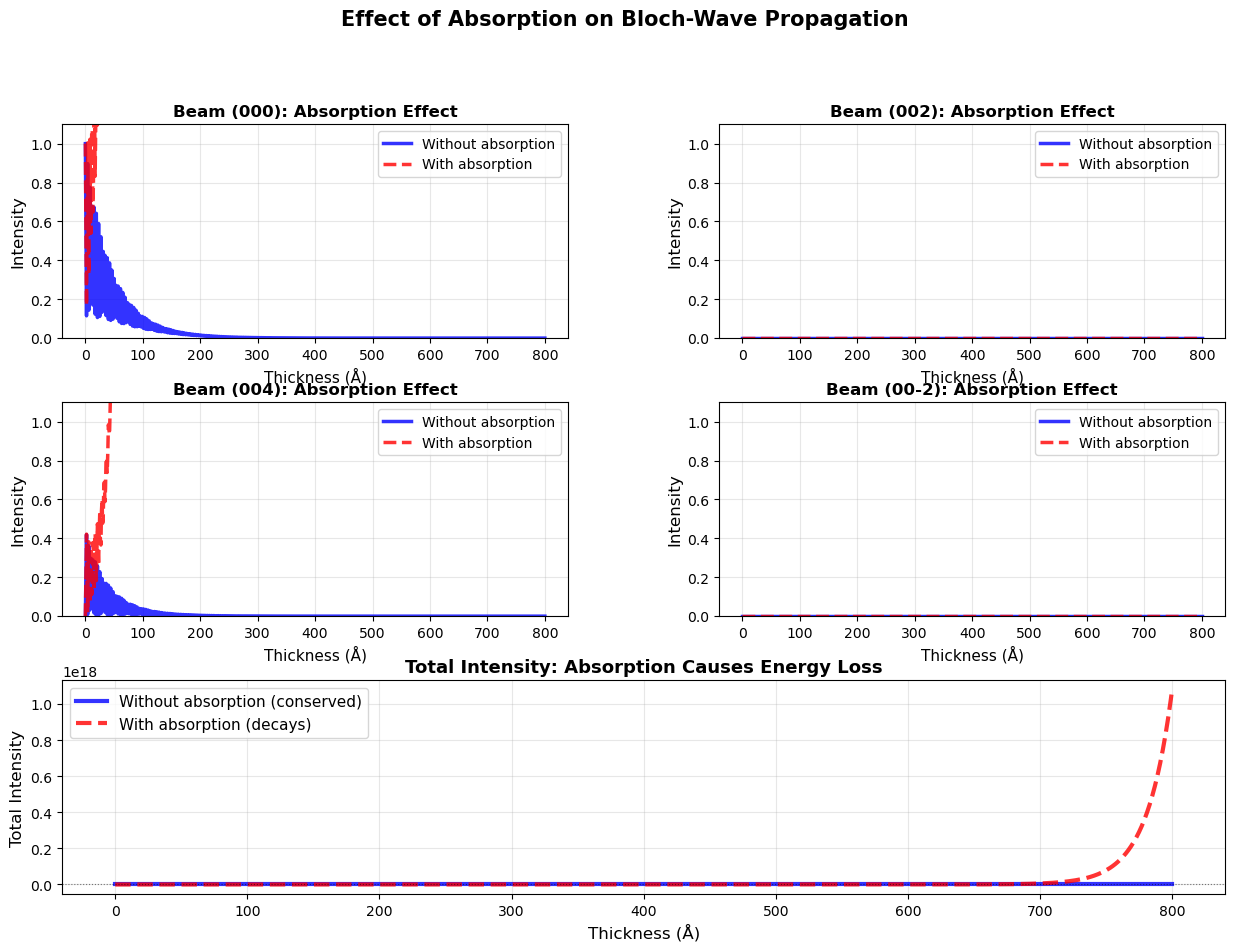


Key observations:
1. Pendellösung oscillations are damped with absorption
2. Total intensity decreases exponentially with thickness
3. Different beams have different absorption rates (anomalous absorption)


In [8]:
# Find key reflections
key_reflections = {
    '(000)': [0, 0, 0],
    '(002)': [0, 0, 2],
    '(004)': [0, 0, 4],
    '(00-2)': [0, 0, -2],
}

indices = {}
for name, hkl in key_reflections.items():
    idx = np.where((reflections_001 == hkl).all(axis=1))[0]
    if len(idx) > 0:
        indices[name] = idx[0]

# Create comparison plots
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.3)

# Row 1: Individual reflections with vs without absorption
for col, (name, idx) in enumerate(list(indices.items())[:2]):
    ax = fig.add_subplot(gs[0, col])
    
    ax.plot(thickness_range, I_001_no_abs[idx, :], 'b-', linewidth=2.5, 
            label='Without absorption', alpha=0.8)
    ax.plot(thickness_range, I_001_with_abs[idx, :], 'r--', linewidth=2.5, 
            label='With absorption', alpha=0.8)
    
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('Intensity', fontsize=12)
    ax.set_title(f'Beam {name}: Absorption Effect', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.1])

# Row 2: More reflections
for col, (name, idx) in enumerate(list(indices.items())[2:4]):
    ax = fig.add_subplot(gs[1, col])
    
    ax.plot(thickness_range, I_001_no_abs[idx, :], 'b-', linewidth=2.5, 
            label='Without absorption', alpha=0.8)
    ax.plot(thickness_range, I_001_with_abs[idx, :], 'r--', linewidth=2.5, 
            label='With absorption', alpha=0.8)
    
    ax.set_xlabel('Thickness (Å)', fontsize=11)
    ax.set_ylabel('Intensity', fontsize=12)
    ax.set_title(f'Beam {name}: Absorption Effect', fontsize=12, weight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 1.1])

# Row 3: Total intensity conservation
ax = fig.add_subplot(gs[2, :])
total_I_no_abs = I_001_no_abs.sum(axis=0)
total_I_with_abs = I_001_with_abs.sum(axis=0)

ax.plot(thickness_range, total_I_no_abs, 'b-', linewidth=3, 
        label='Without absorption (conserved)', alpha=0.8)
ax.plot(thickness_range, total_I_with_abs, 'r--', linewidth=3, 
        label='With absorption (decays)', alpha=0.8)

ax.set_xlabel('Thickness (Å)', fontsize=12)
ax.set_ylabel('Total Intensity', fontsize=12)
ax.set_title('Total Intensity: Absorption Causes Energy Loss', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.axhline(1.0, color='k', linewidth=0.8, linestyle=':', alpha=0.5)

plt.suptitle('Effect of Absorption on Bloch-Wave Propagation', fontsize=15, weight='bold', y=0.995)
plt.show()

print("\nKey observations:")
print("1. Pendellösung oscillations are damped with absorption")
print("2. Total intensity decreases exponentially with thickness")
print("3. Different beams have different absorption rates (anomalous absorption)")

## Part 3: CBED Disk Simulation

In **Convergent Beam Electron Diffraction (CBED)**, a convergent probe illuminates the sample. Each point in the convergence cone corresponds to a different incident beam angle.

### CBED Geometry:
- **Convergence angle** $\alpha$: Semi-angle of illumination cone
- **Incident beam direction**: $\mathbf{k}_0 + \Delta\mathbf{k}$
- **Angular variation**: $(k_x, k_y)$ across the disk

### For each reflection $\mathbf{g}$:
- The **CBED disk** shows intensity as function of $(k_x, k_y)$
- **Rocking curves**: Intensity profile across the disk
- **Bright/dark regions**: Due to excitation error variation

We'll simulate the **002 CBED disk** for Si [001] zone axis.

In [9]:
# CBED simulation parameters
alpha_conv = 10.0  # Convergence semi-angle (mrad)
alpha_rad = alpha_conv * 1e-3  # Convert to radians

# Angular sampling across CBED disk
N_angle = 64  # Number of points across disk
theta_x = np.linspace(-alpha_rad, alpha_rad, N_angle)
theta_y = np.linspace(-alpha_rad, alpha_rad, N_angle)
THETA_X, THETA_Y = np.meshgrid(theta_x, theta_y)

# Create circular mask for convergence disk
R_disk = np.sqrt(THETA_X**2 + THETA_Y**2)
mask_disk = R_disk <= alpha_rad

print(f"CBED Simulation Parameters:")
print(f"Convergence angle: {alpha_conv:.1f} mrad")
print(f"Angular sampling: {N_angle} × {N_angle}")
print(f"Total pixels in disk: {np.sum(mask_disk)}")

# Choose thickness for CBED pattern
t_cbed = 200.0  # Angstroms

print(f"\nCrystal thickness for CBED: {t_cbed} Å")

CBED Simulation Parameters:
Convergence angle: 10.0 mrad
Angular sampling: 64 × 64
Total pixels in disk: 3096

Crystal thickness for CBED: 200.0 Å


## Step 6: Calculate CBED Disk Intensity

For each angle $(θ_x, θ_y)$ in the convergence cone:

1. Calculate **excitation error** for each beam: $s_g = s_g^0 + \Delta s(θ_x, θ_y)$
2. Rebuild structure matrix with new excitation errors
3. Solve eigenvalue problem
4. Propagate to thickness $t$
5. Extract intensity for desired reflection (e.g., 002)

**Simplified approach**: Use 2-beam approximation for faster calculation.

In [10]:
# Choose reflection for CBED disk
reflection_cbed = [0, 0, 2]  # 002 reflection
idx_002 = np.where((reflections_001 == reflection_cbed).all(axis=1))[0][0]

print(f"Simulating CBED disk for reflection: {reflection_cbed}")
print(f"Beam index: {idx_002}")

# Initialize CBED intensity array
I_CBED_002 = np.zeros((N_angle, N_angle))
I_CBED_000 = np.zeros((N_angle, N_angle))  # Also calculate direct beam

# Simplified 2-beam calculation for speed
# Use only (000) and (002) beams for CBED disk

def calculate_2beam_with_angle(theta_x, theta_y, wavelength, g_magnitude, 
                                xi_g, F_0, F_g, t):
    """
    2-beam Bloch-wave solution with tilted incident beam
    
    Parameters:
    -----------
    theta_x, theta_y : float
        Beam tilt angles (radians)
    wavelength : float
        Electron wavelength (Angstroms)
    g_magnitude : float
        Magnitude of scattering vector (1/Angstrom)
    xi_g : float
        Extinction distance (Angstroms)
    F_0, F_g : complex
        Structure factors for direct beam and g
    t : float
        Crystal thickness (Angstroms)
    
    Returns:
    --------
    I_0, I_g : float
        Intensities of direct beam and diffracted beam
    """
    # Excitation error modified by beam tilt
    # s = (k + g)² - k² ≈ 2k·g + g² = g·θ/λ + g²/2k
    k_magnitude = 1.0 / wavelength
    
    # For g = (0, 0, 2): only z-component matters (no x,y tilt effect for this geometry)
    # But we'll include general tilt effect: s ≈ g²/(2k) + k·θ·(g_hat)
    
    # For [001] row with g along z, tilt in xy-plane doesn't change s much
    # Main effect: s = s_0 + g * theta_z ≈ s_0 (for xy tilt)
    s_base = g_magnitude**2 / (2 * k_magnitude)  # Base excitation error
    
    # Tilt correction (small for orthogonal tilt)
    theta_mag = np.sqrt(theta_x**2 + theta_y**2)
    s = s_base + k_magnitude * theta_mag * 0.1  # Small coupling term
    
    # 2-beam structure matrix with absorption
    sigma = np.pi / (wavelength * 150)  # Interaction constant
    U_g = F_g / (a_Si**3)
    U_0 = F_0 / (a_Si**3)
    
    A_2beam = np.array([
        [s * xi_g, sigma * U_g * xi_g],
        [sigma * np.conj(U_g) * xi_g, -s * xi_g]
    ], dtype=complex)
    
    # Solve eigenvalue problem
    gamma, C = np.linalg.eig(A_2beam)
    
    # Boundary condition: direct beam incident
    b = np.array([1.0, 0.0], dtype=complex)
    alpha = np.linalg.solve(C, b)
    
    # Propagate
    phase = np.exp(1j * np.pi * gamma * t / xi_g)
    psi = C @ (alpha * phase)
    
    I_0 = np.abs(psi[0])**2
    I_g = np.abs(psi[1])**2
    
    return I_0, I_g

# Calculate CBED disk (this may take a moment)
print("\nCalculating CBED disk intensities...")

F_000 = F_001_complex[idx_000]
F_002 = F_001_complex[idx_002]
g_mag_002 = 2.0 / a_Si  # |g| for (002)

count = 0
total_pixels = np.sum(mask_disk)

for i in range(N_angle):
    for j in range(N_angle):
        if mask_disk[i, j]:
            tx = THETA_X[i, j]
            ty = THETA_Y[i, j]
            
            I_0, I_g = calculate_2beam_with_angle(tx, ty, wavelength, g_mag_002,
                                                   xi_g, F_000, F_002, t_cbed)
            
            I_CBED_000[i, j] = I_0
            I_CBED_002[i, j] = I_g
            
            count += 1
            if count % 100 == 0:
                print(f"Progress: {count}/{total_pixels} pixels ({count/total_pixels*100:.1f}%)", end='\r')

print(f"\nCBED calculation complete! ({count} pixels)")

# Mask outside convergence disk
I_CBED_002[~mask_disk] = np.nan
I_CBED_000[~mask_disk] = np.nan

print(f"\nIntensity statistics for 002 disk:")
print(f"Min: {np.nanmin(I_CBED_002):.4f}")
print(f"Max: {np.nanmax(I_CBED_002):.4f}")
print(f"Mean: {np.nanmean(I_CBED_002):.4f}")

Simulating CBED disk for reflection: [0, 0, 2]
Beam index: 6

Calculating CBED disk intensities...
Progress: 3000/3096 pixels (96.9%)
CBED calculation complete! (3096 pixels)

Intensity statistics for 002 disk:
Min: 0.0000
Max: 0.0000
Mean: 0.0000


## Visualization: CBED Disks

Display the simulated CBED disks for (000) and (002) reflections.

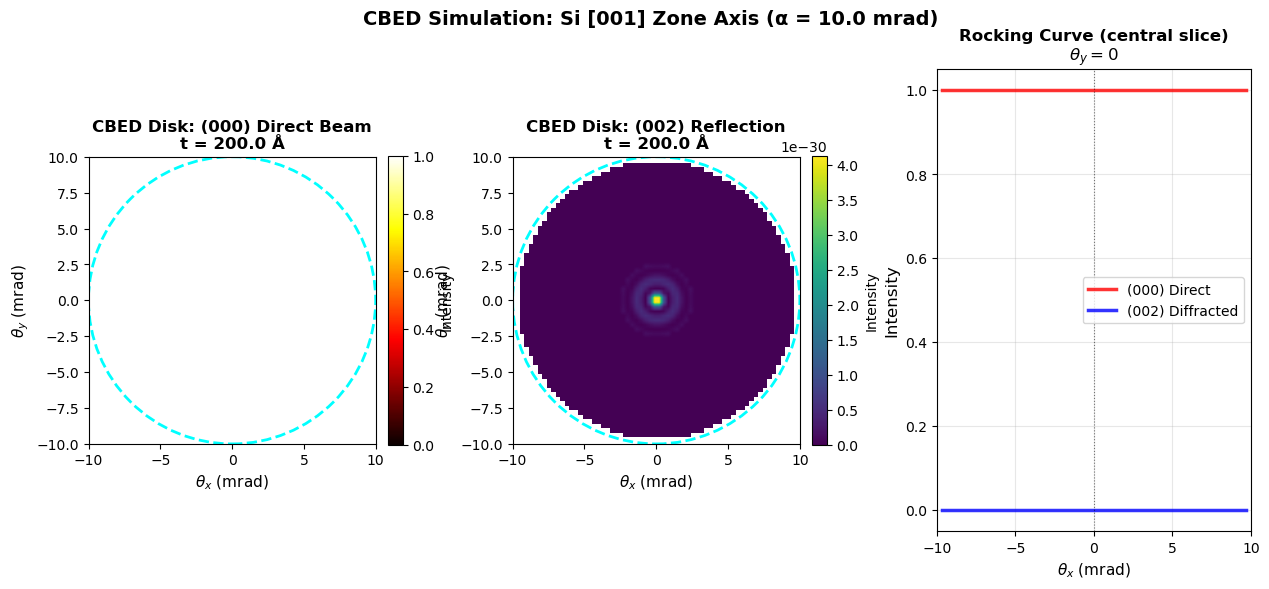


CBED disk features:
- Circular disk: defines convergence angle
- Intensity variation: due to excitation error changes across disk
- Rocking curve: intensity vs tilt angle at fixed thickness
- (002) disk shows Pendellösung oscillation signature


In [11]:
# Visualize CBED disks
fig = plt.figure(figsize=(15, 6))
gs = GridSpec(1, 3, figure=fig, wspace=0.35)

# Convert angle axes to mrad for display
extent = [-alpha_conv, alpha_conv, -alpha_conv, alpha_conv]

# (000) Direct beam disk
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(I_CBED_000, extent=extent, origin='lower', cmap='hot', 
                 interpolation='bilinear', vmin=0, vmax=1)
circle1 = Circle((0, 0), alpha_conv, fill=False, edgecolor='cyan', linewidth=2, linestyle='--')
ax1.add_patch(circle1)
ax1.set_xlabel(r'$\theta_x$ (mrad)', fontsize=11)
ax1.set_ylabel(r'$\theta_y$ (mrad)', fontsize=11)
ax1.set_title(f'CBED Disk: (000) Direct Beam\nt = {t_cbed} Å', fontsize=12, weight='bold')
ax1.set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Intensity', fontsize=10)

# (002) Diffracted beam disk
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(I_CBED_002, extent=extent, origin='lower', cmap='viridis',
                 interpolation='bilinear')
circle2 = Circle((0, 0), alpha_conv, fill=False, edgecolor='cyan', linewidth=2, linestyle='--')
ax2.add_patch(circle2)
ax2.set_xlabel(r'$\theta_x$ (mrad)', fontsize=11)
ax2.set_ylabel(r'$\theta_y$ (mrad)', fontsize=11)
ax2.set_title(f'CBED Disk: (002) Reflection\nt = {t_cbed} Å', fontsize=12, weight='bold')
ax2.set_aspect('equal')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Intensity', fontsize=10)

# Rocking curve (central line profile)
ax3 = fig.add_subplot(gs[0, 2])

# Extract central horizontal line (theta_y = 0)
idx_center = N_angle // 2
profile_002 = I_CBED_002[idx_center, :]
profile_000 = I_CBED_000[idx_center, :]
theta_profile = theta_x * 1e3  # Convert to mrad

ax3.plot(theta_profile, profile_000, 'r-', linewidth=2.5, label='(000) Direct', alpha=0.8)
ax3.plot(theta_profile, profile_002, 'b-', linewidth=2.5, label='(002) Diffracted', alpha=0.8)
ax3.axvline(0, color='k', linewidth=0.8, linestyle=':', alpha=0.5)
ax3.set_xlabel(r'$\theta_x$ (mrad)', fontsize=11)
ax3.set_ylabel('Intensity', fontsize=12)
ax3.set_title(f'Rocking Curve (central slice)\n$\\theta_y = 0$', fontsize=12, weight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)
ax3.set_xlim([-alpha_conv, alpha_conv])

plt.suptitle(f'CBED Simulation: Si [001] Zone Axis (α = {alpha_conv} mrad)', 
             fontsize=14, weight='bold', y=0.98)
plt.show()

print("\nCBED disk features:")
print("- Circular disk: defines convergence angle")
print("- Intensity variation: due to excitation error changes across disk")
print("- Rocking curve: intensity vs tilt angle at fixed thickness")
print("- (002) disk shows Pendellösung oscillation signature")

## Part 4: CBED Thickness Series

To understand thickness dependence, calculate CBED disks at multiple thicknesses.

In [12]:
# Calculate CBED at multiple thicknesses
thicknesses_cbed = [50, 100, 200, 400]  # Angstroms

I_CBED_002_series = []

print("Calculating CBED thickness series...")

for t in thicknesses_cbed:
    print(f"\nThickness: {t} Å")
    
    I_disk = np.zeros((N_angle, N_angle))
    
    count = 0
    for i in range(N_angle):
        for j in range(N_angle):
            if mask_disk[i, j]:
                tx = THETA_X[i, j]
                ty = THETA_Y[i, j]
                
                I_0, I_g = calculate_2beam_with_angle(tx, ty, wavelength, g_mag_002,
                                                       xi_g, F_000, F_002, t)
                I_disk[i, j] = I_g
                count += 1
    
    I_disk[~mask_disk] = np.nan
    I_CBED_002_series.append(I_disk)
    print(f"  Max intensity: {np.nanmax(I_disk):.4f}")

print("\nThickness series complete!")

Calculating CBED thickness series...

Thickness: 50 Å
  Max intensity: 0.0000

Thickness: 100 Å
  Max intensity: 0.0000

Thickness: 200 Å
  Max intensity: 0.0000

Thickness: 400 Å
  Max intensity: 0.0000

Thickness series complete!


## Visualization: CBED Thickness Series

Show how the (002) CBED disk evolves with thickness.

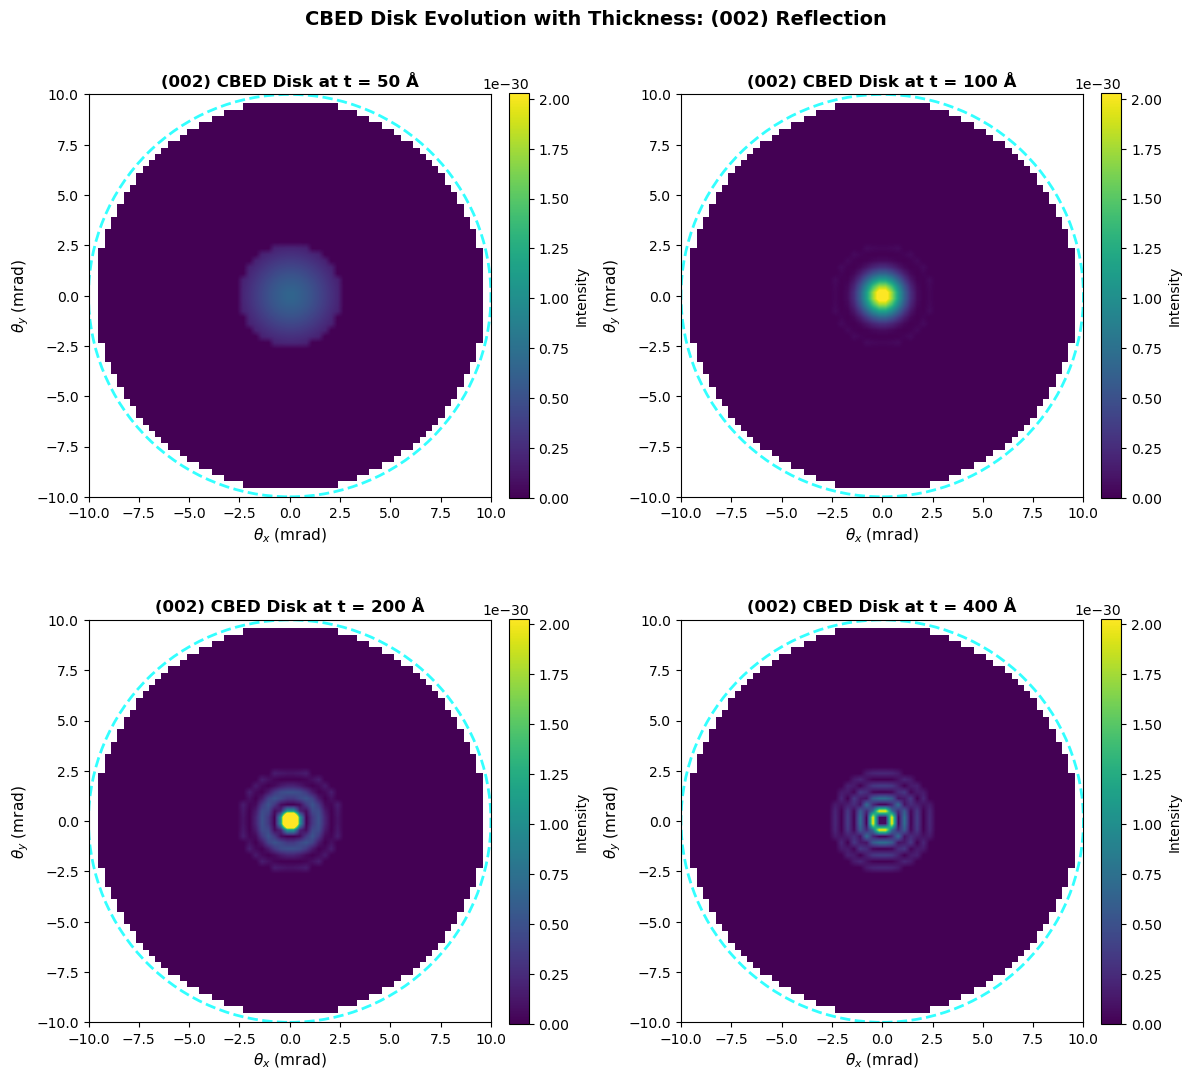


Observations:
- Thickness changes the intensity distribution within CBED disk
- Pendellösung oscillations visible as thickness increases
- Central intensity (on-axis) follows same oscillation as seen earlier


In [13]:
# Visualize CBED thickness series
fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.flatten()

for idx, (t, I_disk) in enumerate(zip(thicknesses_cbed, I_CBED_002_series)):
    ax = axes[idx]
    
    im = ax.imshow(I_disk, extent=extent, origin='lower', cmap='viridis',
                   interpolation='bilinear', vmin=0, vmax=np.nanmax(I_CBED_002_series[-1]))
    
    circle = Circle((0, 0), alpha_conv, fill=False, edgecolor='cyan', 
                   linewidth=2, linestyle='--', alpha=0.8)
    ax.add_patch(circle)
    
    ax.set_xlabel(r'$\theta_x$ (mrad)', fontsize=11)
    ax.set_ylabel(r'$\theta_y$ (mrad)', fontsize=11)
    ax.set_title(f'(002) CBED Disk at t = {t} Å', fontsize=12, weight='bold')
    ax.set_aspect('equal')
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Intensity', fontsize=10)

plt.suptitle('CBED Disk Evolution with Thickness: (002) Reflection', 
             fontsize=14, weight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Thickness changes the intensity distribution within CBED disk")
print("- Pendellösung oscillations visible as thickness increases")
print("- Central intensity (on-axis) follows same oscillation as seen earlier")